In [1]:
import ROOT
import warnings

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

from scipy import integrate
from lmfit import Parameters, minimize

from scipy.optimize import curve_fit 
from tqdm import tqdm

from scipy.signal import fftconvolve
from scipy.special import gamma

from pyazr import azure2

warnings.filterwarnings('ignore')

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

print( 'Doppler effect =', dopp )

Doppler effect = 0.02839149987232094


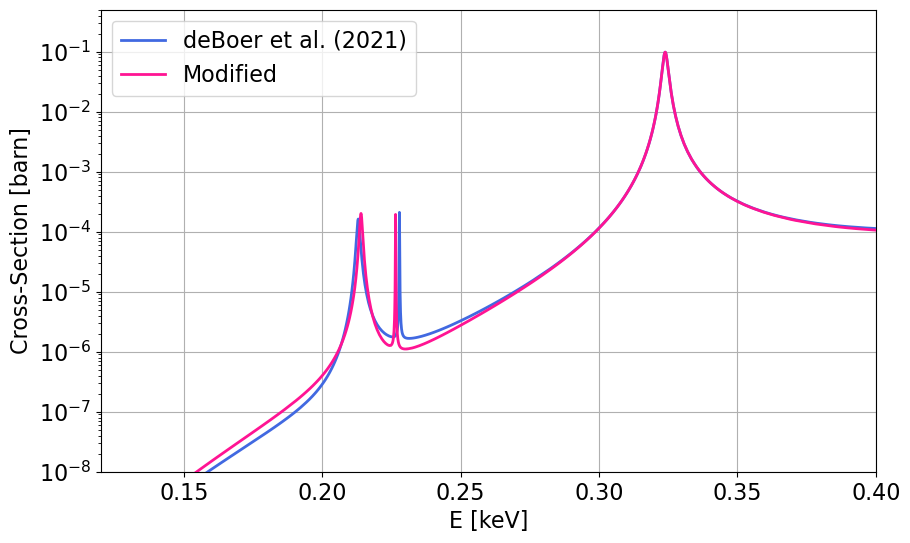

In [2]:
# Read cross-section
data_old = np.loadtxt( "utils/19F_pag_50-450keV.extrap", usecols=(0,3))
energies_old, extrap_old = data_old[:,0], data_old[:,1]

data = np.loadtxt( "utils/all_imp.extrap", usecols=(0,3) )
energies, extrap = data[:,0], data[:,1]

plt.figure( figsize=(10,6) )
plt.plot(energies_old, extrap_old, color="royalblue", label="deBoer et al. (2021)", zorder=5, lw=2)
plt.plot(energies, extrap, color="deeppink", label="Modified", zorder=6, lw=2)
plt.yscale("log")
plt.legend(fontsize=16)
plt.grid()
plt.xlabel("E [keV]")
plt.ylabel("Cross-Section [barn]")
plt.xlim(0.12, 0.40)
plt.ylim(1e-8, 5e-1)
plt.savefig('CrossSection_Comparison.png', dpi=300, bbox_inches='tight')
plt.show( )

# data_noRES = np.loadtxt( "utils/19F_pag_50-400keV_noRES.extrap", usecols=(0,3) )
# energies_noRES, extrap_noRES = data_noRES[:,0], data_noRES[:,1]

# data_340 = np.loadtxt( "utils/19F_pag_50-450keV_noRES.extrap", usecols=(0,3) )
# energies_340, extrap_340 = data_340[:,0], data_340[:,1]

# plt.figure( figsize=(10,6) )
# plt.plot(data[:,0], data[:,1], color="royalblue", label="225+240+340+DC", zorder=5, lw=2)
# plt.plot(data_340[:,0], data_340[:,1], color="deeppink", ls=(0,(4,3)), label="340+DC only", zorder=6, lw=2)
# # plt.plot(data_noRES[:,0], data_noRES[:,1], color="forestgreen", label="DC only", zorder=3, lw=2)
# plt.yscale("log")
# plt.legend(fontsize=16)
# plt.grid()
# plt.xlabel("E [keV]")
# plt.ylabel(r"Cross-Section [a.u.]")
# plt.xlim(0.05, 0.35)
# plt.show( )

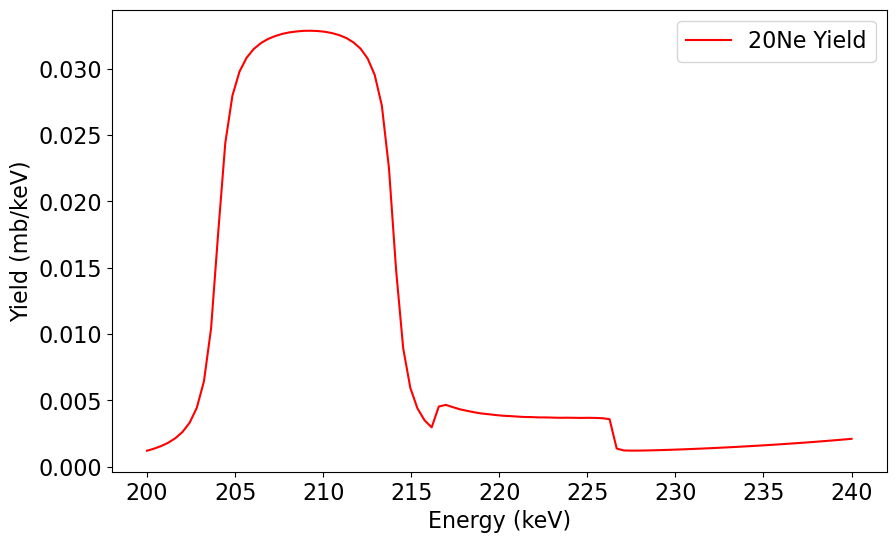

In [ ]:
def cross_section( x0 ):
    cross = np.interp( x0, energies * 1e3, extrap * 1e3 )
    return cross

# Calculate the yield by integrating the cross section over the energy loss of 10 keV
def yield_integral( energy, de ):
    grid = np.linspace( energy, energy + de, 1000 )
    integral = np.trapz( cross_section( grid ), grid )
    return integral / de

x = np.linspace( 200, 240, 100 )

yields = [ yield_integral( e, 10 ) for e in x ]

plt.figure( figsize=( 10, 6 ) )
plt.plot( x, yields, label='20Ne Yield', color='red' )
plt.xlabel( 'Energy (keV)' )
plt.ylabel( 'Yield (mb/keV)' )
plt.legend()
plt.show()

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import integrate
from lmfit import Parameters, minimize

from scipy.special import gamma

from pyazr import azure2

from SRIM import SRIM
from scipy.special import erf

warnings.filterwarnings('ignore')

# Select target
target = 'IMP_LFE#2'

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

print( 'Doppler effect =', dopp )

# Read the element stopping data
H_in_F = SRIM( "stopping/H_in_F.stop" )
H_in_H = SRIM( "stopping/H_in_H.stop" )
H_in_Fe = SRIM( "stopping/H_in_Fe.stop" )
H_in_Ta = SRIM( "stopping/H_in_Ta.stop" )
H_in_Ca = SRIM( "stopping/H_in_Ca.stop" )

# Get the effective stopping power for CaF2
def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

# Starggling
popt = [0.75324712]
def straggling( x ):
    return popt[0] * np.sqrt( x )

def gaussian( x, x0, s ):
    return np.exp( -(x - x0)**2 / ( s*s*2 ) )

def profile( de, theta ):
    # Gaussian
    # if de <= 0: return 0
    # else: return gaussian( de, theta["mean"], theta["std"] ) # + 0.5*gaussian( de, theta["mean2"], theta["std2"] )
    # return gaussian( de, theta["mean"], theta["std"] )
    
    # # Square
    # return 1 if de > 0 and de < theta["width"] else 0
    # if de > 0 and de < theta["width"]:
    #     return 1
    # elif de > theta["width"] and de < theta["width2"] + theta["width"]:
    #     return 0.65
    # elif de > theta["width2"] + theta["width"] and de < theta["width2"] + theta["width"] + theta["width3"]:
    #     # return 0.09
    #     return 3.5/de
    # else:
    #     return 0
    if de > 0 and de < theta["width"]:
        return 1 - ( de / theta["width"] )*0.4
    elif de > theta["width"] and de < theta["width2"] + theta["width"]:
        return 0.6
    elif de > theta["width2"] + theta["width"] and de < theta["width2"] + theta["width"] + theta["width3"]:
        # return 0.09
        return 2.5/de
    else:
        return 0

def cross_section( x0, theta, de ):
    cross = np.interp( x0, energies * 1e3, extrap )
    return cross 

def reaction_yield( x0, theta, de ):
    cross = cross_section( x0, theta, de ) * 1e-24
    stop = effective_stopping_Fe( x0, theta["n_fe"], theta["n_f"] ) * 1e-15 * 1e-3
    p = profile( de, theta )
    return cross / stop * p

def integrand( x, theta, x0 ):
    de = x0 - x
    
    # Get beam width
    s = np.sqrt( pow( theta["beam"], 2 ) + pow( dopp, 2 ) )
    s = np.sqrt( pow( theta["strag"] * straggling( de ), 2 ) + pow(s, 2) ) if de > 0 else s

    # Convolve the gaussian with the straggling
    array = np.linspace( x - 3 * s, x + 3 * s, 100 )
    gauss = gaussian( array, x, s )

    # Normalize the gaussian
    step = array[1] - array[0]
    norm  = np.sum( gauss ) * step
    
    # Convolve
    conv = np.sum( gauss * reaction_yield( array, theta, de ) ) * step / norm

    #return reaction_yield( x, theta, de )
    return conv

def straggled_profile( x, theta ):
    y = np.zeros( shape=len( x ) )
    for idx in range( len( x ) ):
        nsteps = 500
        xmin, xmax = x[idx] - 50, x[idx]
        dx = np.abs( xmax - xmin ) / nsteps
        y[idx] = integrate.simpson( [ integrand( x_i, theta, x[idx] ) for x_i in np.linspace( xmin, xmax, nsteps) ], dx=dx )
    return y

def model( x, theta ):
    sign = straggled_profile( x, theta )
    back = 0
    return sign + back

def chi2( theta ):
    theta = list( theta.valuesdict().values() )
    mod   = model( x, theta )
    res   = ( obs - mod ) / err
    print( "Chi2: {:10.4f}".format(np.sum(res**2)), end="\r" )
    return res

Doppler effect = 0.02839149987232094


In [ ]:
# Read the CSV file of yield for the target
df = pd.read_csv(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target}.csv")

scan = 1

df = df[df["Scan"] == f"Scan {scan}"]

# Recover the very first scan
x, y, y_err = df["Energy"], df["Yield"], df["Yield Error"]

# Refine the yield data by selecting only points with E not NaN and E<300 keV
mask = (~np.isnan(x)) & (x < 300)
x = x[mask]
y = y[mask]
y_err = y_err[mask]

x.to_numpy()
y.to_numpy()
y_err.to_numpy()

eff = 0.689
q_e = 1.602176634e-19

# N_reactions / N_protons
#y = y * q_e / eff
#yerr = yerr * q_e / eff

# Convert to CM
x = x * 19 / 20.007

# Read cross-section
# data = np.loadtxt( "utils/19F_pag_200-260keV.extrap", usecols=(0,3))
data = np.loadtxt( "utils/19F_pag_50-450keV.extrap", usecols=(0,3) )
energies, extrap = data[:,0], data[:,1]

# data_noRES = np.loadtxt( "utils/19F_pag_50-400keV_noRES.extrap", usecols=(0,3) )
# energies, extrap = data_noRES[:,0], data_noRES[:,1]*(data_noRES[:,1])**(1/11)*42

In [ ]:
params = Parameters()

# Beam width (keV)
params.add('beam', value=0.12, vary=False)

# Fluorine Tantalum layer
params.add('n_fe', value=1.95, vary=True) # Ta stoichiometry
params.add('n_f', value=1, vary=True) # F stoichiometry

# Straggling coefficient
params.add('strag', value=1, vary=False) # Straggling

# If square
params.add('width', value=8.5, vary=True)
params.add('width2', value=9, vary=True)
params.add('width3', value=30, vary=True)

# If gaussian
params.add('mean', value=4.5, vary=True)    # Center of the profile
params.add('std', value=3.25, vary=True)     # Width of the profile

# Calculate
grid = np.linspace( 180, 300, 500 )
y_mod = model( grid, params )

KeyboardInterrupt: 

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import integrate
from lmfit import Parameters, minimize

from scipy.special import gamma

from pyazr import azure2

from SRIM import SRIM
from scipy.special import erf

warnings.filterwarnings('ignore')

# Select target
target = 'IMP_LFE#2'

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

print( 'Doppler effect =', dopp )

# Read the element stopping data
H_in_F = SRIM( "stopping/H_in_F.stop" )
H_in_H = SRIM( "stopping/H_in_H.stop" )
H_in_Fe = SRIM( "stopping/H_in_Fe.stop" )
H_in_Ta = SRIM( "stopping/H_in_Ta.stop" )
H_in_Ca = SRIM( "stopping/H_in_Ca.stop" )

# Get the effective stopping power for CaF2
def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

# Starggling
popt = [0.75324712]
def straggling( x ):
    return popt[0] * np.sqrt( x )

def gaussian( x, x0, s ):
    return np.exp( -(x - x0)**2 / ( s*s*2 ) )

def profile( de, theta ):
    # Gaussian
    # if de <= 0: return 0
    # else: return gaussian( de, theta["mean"], theta["std"] ) # + 0.5*gaussian( de, theta["mean2"], theta["std2"] )
    # return gaussian( de, theta["mean"], theta["std"] )
    
    # # Square
    # return 1 if de > 0 and de < theta["width"] else 0
    if de > 0 and de < theta["width"]:
        return 1
    elif de > theta["width"] and de < theta["width2"] + theta["width"]:
        return 0.65
    elif de > theta["width2"] + theta["width"] and de < theta["width2"] + theta["width"] + theta["width3"]:
        # return 0.09
        return 3.5/de
    else:
        return 0

def cross_section( x0, theta, de ):
    cross = np.interp( x0, energies * 1e3, extrap )
    return cross 

def reaction_yield( x0, theta, de ):
    cross = cross_section( x0, theta, de ) * 1e-24
    stop = effective_stopping_Fe( x0, theta["n_fe"], theta["n_f"] ) * 1e-15 * 1e-3
    p = profile( de, theta )
    return cross / stop * p

def integrand( x, theta, x0 ):
    de = x0 - x
    
    # Get beam width
    s = np.sqrt( pow( theta["beam"], 2 ) + pow( dopp, 2 ) )
    s = np.sqrt( pow( theta["strag"] * straggling( de ), 2 ) + pow(s, 2) ) if de > 0 else s

    # Convolve the gaussian with the straggling
    array = np.linspace( x - 3 * s, x + 3 * s, 100 )
    gauss = gaussian( array, x, s )

    # Normalize the gaussian
    step = array[1] - array[0]
    norm  = np.sum( gauss ) * step
    
    # Convolve
    conv = np.sum( gauss * reaction_yield( array, theta, de ) ) * step / norm

    #return reaction_yield( x, theta, de )
    return conv

def straggled_profile( x, theta ):
    y = np.zeros( shape=len( x ) )
    for idx in range( len( x ) ):
        nsteps = 500
        xmin, xmax = x[idx] - 50, x[idx]
        dx = np.abs( xmax - xmin ) / nsteps
        y[idx] = integrate.simpson( [ integrand( x_i, theta, x[idx] ) for x_i in np.linspace( xmin, xmax, nsteps) ], dx=dx )
    return y

def model( x, theta ):
    sign = straggled_profile( x, theta )
    back = 0
    return sign + back

def chi2( theta ):
    theta = list( theta.valuesdict().values() )
    mod   = model( x, theta )
    res   = ( obs - mod ) / err
    print( "Chi2: {:10.4f}".format(np.sum(res**2)), end="\r" )
    return res

Doppler effect = 0.02839149987232094


In [ ]:
# Read the CSV file of yield for the target
df = pd.read_csv(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target}.csv")

scan = 1

df = df[df["Scan"] == f"Scan {scan}"]

# Recover the very first scan
x, y, y_err = df["Energy"], df["Yield"], df["Yield Error"]

# Refine the yield data by selecting only points with E not NaN and E<300 keV
mask = (~np.isnan(x)) & (x < 300)
x = x[mask]
y = y[mask]
y_err = y_err[mask]

x.to_numpy()
y.to_numpy()
y_err.to_numpy()

eff = 0.689
q_e = 1.602176634e-19

# N_reactions / N_protons
#y = y * q_e / eff
#yerr = yerr * q_e / eff

# Convert to CM
x = x * 19 / 20.007

# Read cross-section
# data = np.loadtxt( "utils/19F_pag_200-260keV.extrap", usecols=(0,3))
# data = np.loadtxt( "utils/19F_pag_50-450keV.extrap", usecols=(0,3) )
# energies, extrap = data[:,0], data[:,1]

data_340 = np.loadtxt( "utils/19F_pag_50-450keV_noRES.extrap", usecols=(0,3) )
energies, extrap = data_340[:,0], data_340[:,1]

In [ ]:
params = Parameters()

# Beam width (keV)
params.add('beam', value=0.12, vary=False)

# Fluorine Tantalum layer
params.add('n_fe', value=1.95, vary=True) # Ta stoichiometry
params.add('n_f', value=1, vary=True) # F stoichiometry

# Straggling coefficient
params.add('strag', value=1, vary=False) # Straggling

# If square
params.add('width', value=8.5, vary=True)
params.add('width2', value=0, vary=True)
params.add('width3', value=0, vary=True)

# If gaussian
params.add('mean', value=4.5, vary=True)    # Center of the profile
params.add('std', value=3.25, vary=True)     # Width of the profile

# Calculate
grid = np.linspace( 180, 300, 500 )
y_mod_340 = model( grid, params )

In [ ]:
data_340 = np.loadtxt( "utils/19F_pag_50-450keV_noRES.extrap", usecols=(0,3) )
energies, extrap = data_340[:,0], data_340[:,1]

# Calculate
grid = np.linspace( 180, 300, 500 )
y_mod_noRES = model( grid, params )

In [ ]:
def mimic_340(x, a,b,c):
    return a*b**(x-c)
    # return a*x**5 + b*x**4 + c*x**3 + d*x**2 + e*x + f
    # return a*np.sin(b*(x-c))

from scipy.optimize import curve_fit

mask = (grid*20/19 > 180) & (grid*20/19 < 280)

popt, pcov = curve_fit( mimic_340, grid[mask]*20/19, (y_mod_340 / q_e / 1e6 * eff)[mask], p0=[0.5, 1.055, 236], maxfev=10000 )
# popt, pcov = curve_fit( mimic_340, grid[mask]*20/19, (y_mod_340 / q_e / 1e6 * eff)[mask], maxfev=10000 )

print(popt)

[  0.2684127    1.05948667 235.55827583]


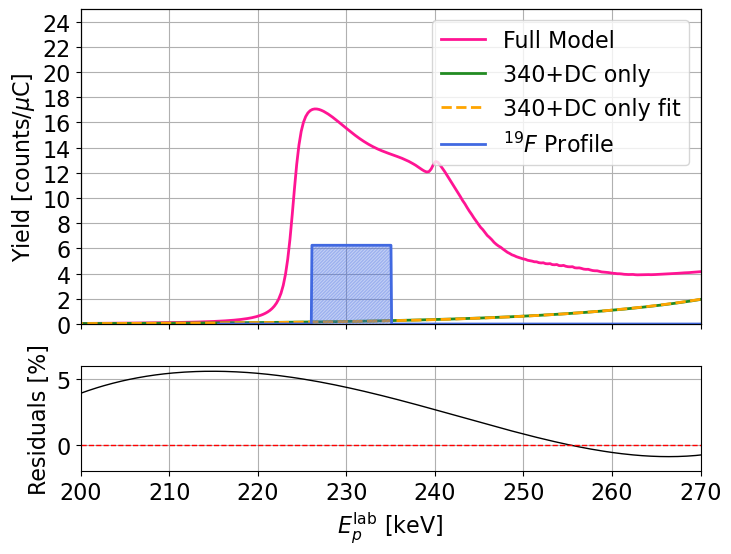

214.8

In [ ]:
# Scale
scale_model = 1

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Calculate residuals
residuals = (y_mod_340 / q_e / 1e6 * eff - mimic_340(grid*20/19, *popt)) / (y_mod_340 / q_e / 1e6 * eff)

# Plot residuals
ax_res.plot(grid*20/19, residuals * 100, color='black', lw=1)
ax_res.axhline(0, color='red', ls='--', lw=1)
ax_res.set_ylabel('Residuals [%]')
ax_res.set_xlabel(r'$E_p^\text{lab}$ [keV]')
ax_res.set_ylim(-2, 6)
ax_res.grid()

# Plot
# ax.errorbar( x, y, yerr=y_err, fmt='o', label='Data', color='black', capsize=5 )
ax.plot( grid*20/19, y_mod / q_e / 1e6 * eff, ls='solid', lw=2, color='deeppink', label='Full Model' )
ax.plot( grid*20/19, y_mod_340 / q_e / 1e6 * eff, ls='solid', lw=2, color='forestgreen', label='340+DC only' )
# # ax.plot( grid*20/19, y_mod_noRES / q_e / 1e6 * eff, ls='dashed', lw=2, color='orange', label='Model direct capture' )
# # ax.plot( grid*20/19, 0.5*1.055**((grid*20/19)-236), ls='dashed', lw=2, color='orange', label='Background Fit' )
ax.plot( grid*20/19, mimic_340(grid*20/19, *popt), ls='dashed', lw=2, color='orange', label='340+DC only fit' )

ax.set_ylabel( r'Yield [counts/$\mu$C]')
# ax.set_xlabel( r'$E_p^\text{lab}$ [keV]' )

ax.set_ylim(0, 25)
ax.set_yticks( np.arange( 0, 25, 2 ) )

# Plot cross section with the same scale
# grid_cross = np.linspace( 205, 250, 10000 )
# y_cross = np.interp( grid_cross, energies * 1e3, extrap )
# y_cross = y_cross / np.max( y_cross ) * np.max( y_mod ) * 0.9
# plt.plot( grid_cross, y_cross, '--', lw=2, label='Cross Section' )

ax2 = ax.twinx()
grid_profile = np.linspace( -10, 60, 1000 )
p = []
for de in grid_profile:
    p.append( profile( de, params ) )
p = np.array( p )
grid_profile += 214.8
ax2.plot( grid_profile*20/19, p, ls='solid', lw=2, label=r'${}^{19}F$ Profile', color='royalblue' )
ax2.fill_between( grid_profile*20/19, 0, p, color='royalblue', hatch='//////////', alpha=0.3 )

# Put ax and ax2 legends together the legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=16)

# Remove all labels and ticks from ax2
ax2.set_yticks([])
ax2.set_ylabel('')

ax.set_xlim(200, 270)
ax.grid()
ax2.set_xlim(200, 270)
ax2.set_ylim(0, 4)

# plt.savefig( f"results/{target}_240_scan{scan}.png", dpi=300, bbox_inches='tight' )
plt.show( )



227.9
214.8

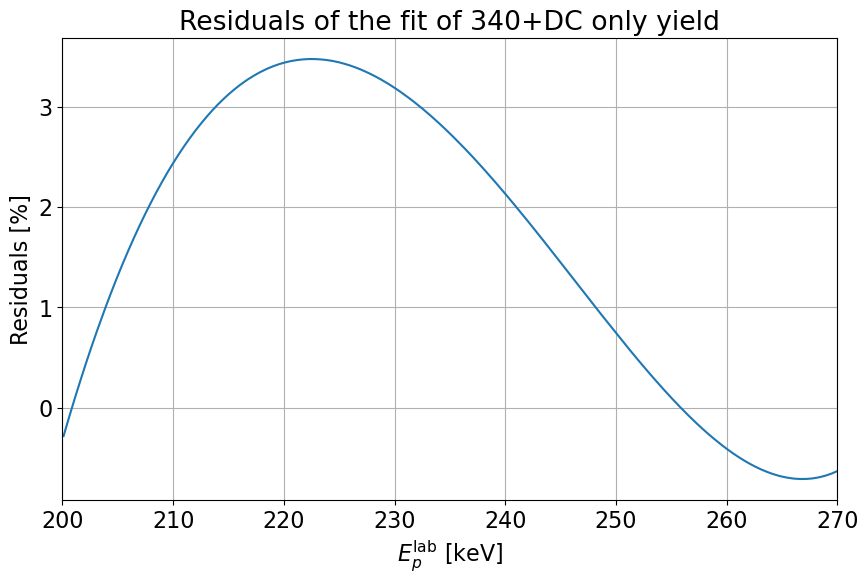

In [ ]:
# Plot residurals
mask = (grid*20/19 > 200) & (grid*20/19 < 270)
f0 = mimic_340(grid[mask]*20/19, *popt)
f1 = (y_mod_340 / q_e / 1e6 * eff)[mask]

residuals = (f1 - f0) / f1

plt.figure( figsize=( 10, 6 ) )
# plt.yscale('symlog', linthresh=1e-2)
plt.title('Residuals of the fit of 340+DC only yield')
plt.xlabel( r'$E_p^\text{lab}$ [keV]' )
plt.ylabel( 'Residuals [%]' )
plt.plot( grid[mask]*20/19, residuals*100 )
plt.xlim(200, 270)
plt.grid()
plt.show()

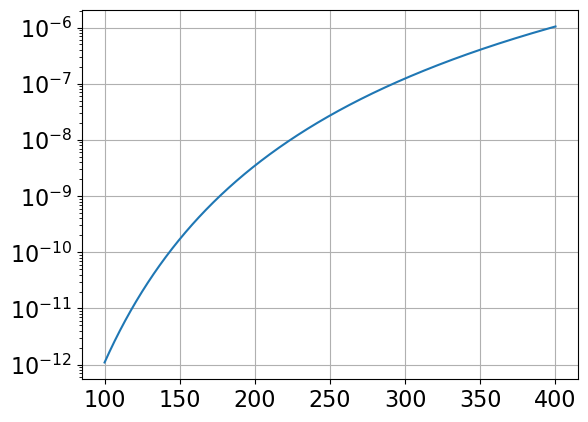

In [ ]:
E = np.linspace(100,400,1000)
# def gamow_factor(E):
#     Z1 = 1
#     Z2 = 9
#     mu = 19 / (19 + 1) #* 1.0072764668124  # in amu
#     mu = mu #* 931.49410242e6  # in eV/c^2
#     # ħc in eV·fm
#     hbarc = 197.3269804e6
#     eta = 0.98951013 * Z1 * Z2 * np.sqrt(mu / (E/1e3)) / (2 * np.pi)
#     # eta = Z1 * Z2 * 1.4399764e6 / hbarc * np.sqrt(mu / (2 * E * 1e3))
#     return np.exp(-2 * np.pi * eta)
# sigma = gamow_factor(E)

Z0, Z1 = 1, 9
M0, M1 = 1.0072764668124, 18.998403163
mu = M0 * M1 / (M0 + M1)

def exp_2pi_eta(E):
    eta = 0.98951013 * Z0 * Z1 * np.sqrt(mu / (E/1e3)) / (2 * np.pi)
    return np.exp(-2 * np.pi * eta)

kT = 0.086173324 * 0.1 # 0.1 GK

def exp_E_kt(E):
    return np.exp(-E / kT)

def integrand(E):
    return exp_2pi_eta(E) * exp_E_kt(E)

sigma = exp_2pi_eta(E)

plt.yscale("log")
plt.plot(E, sigma)
plt.grid()
plt.show()

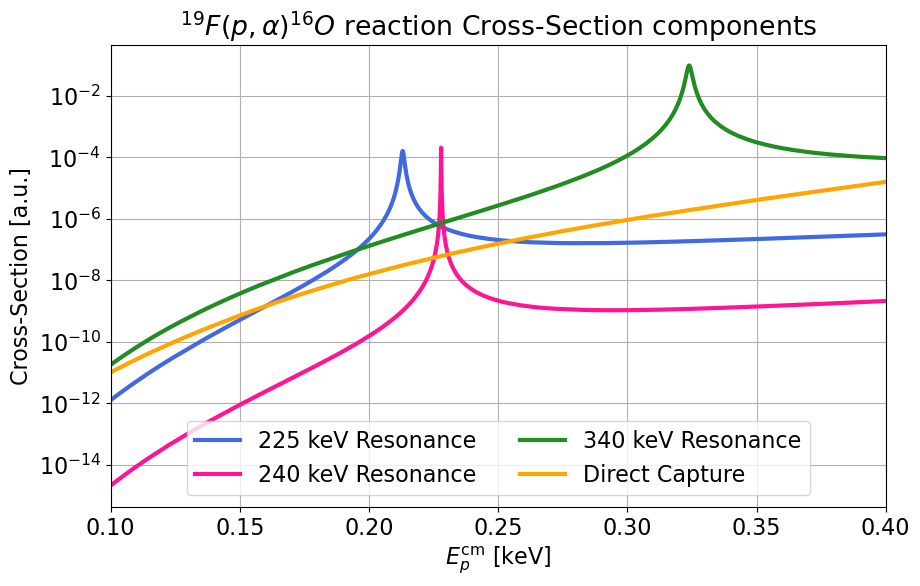

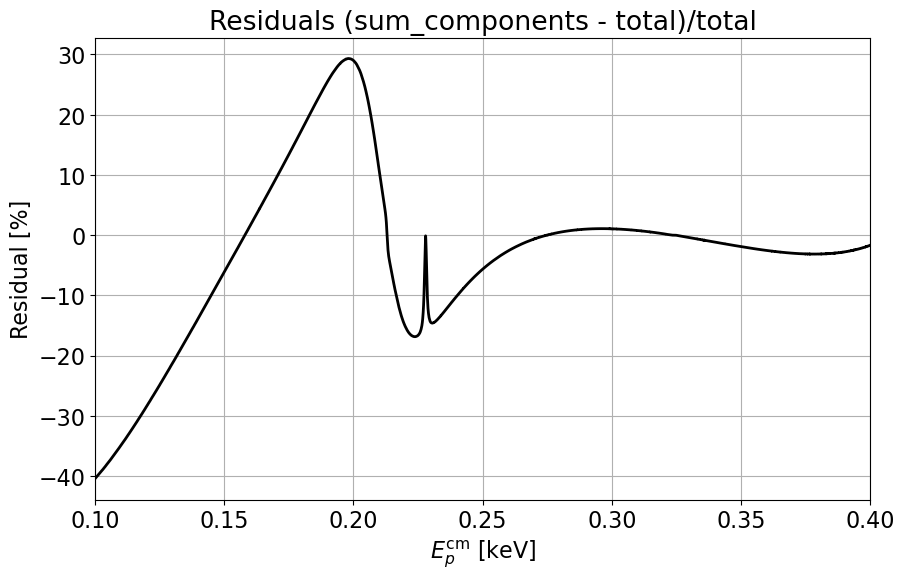

In [ ]:
data = np.loadtxt( "utils/225keV_only.extrap", usecols=(0,3))
E_225, sigma_225 = data[:,0], data[:,1]

data = np.loadtxt( "utils/240keV_only.extrap", usecols=(0,3))
E_240, sigma_240 = data[:,0], data[:,1]

data = np.loadtxt( "utils/340keV_only.extrap", usecols=(0,3))
E_340, sigma_340 = data[:,0], data[:,1]

data = np.loadtxt( "utils/DC_only.extrap", usecols=(0,3))
E_DC, sigma_DC = data[:,0], data[:,1]

data = np.loadtxt( "utils/19F_pag_50-450keV.extrap", usecols=(0,3))
E_tot, sigma_tot = data[:,0], data[:,1]

check = sigma_225 + sigma_240 + sigma_340 + sigma_DC

mask = (E_tot > 0.10) & (E_tot < 0.40)
E_tot = E_tot[mask]
sigma_tot = sigma_tot[mask]
check = check[mask]
E_225 = E_225[mask]
sigma_225 = sigma_225[mask]
E_240 = E_240[mask]
sigma_240 = sigma_240[mask]
E_340 = E_340[mask]
sigma_340 = sigma_340[mask]
E_DC = E_DC[mask]
sigma_DC = sigma_DC[mask]

plt.figure( figsize=(10,6) )
plt.yscale("log")
plt.title(r"${}^{19}F(p,\alpha){}^{16}O$ reaction Cross-Section components")
# plt.plot(E_tot, sigma_tot, label="Total Cross-Section", color="black", lw=3, ls=(0,(2,2)), zorder=3)
# plt.plot(E_tot, check, label="Sum of Single Components", color="crimson", lw=3, ls=(0,(2,2)), zorder=5)
plt.plot(E_225, sigma_225, label="225 keV Resonance", color="royalblue", lw=3)
plt.plot(E_240, sigma_240, label="240 keV Resonance", color="deeppink", lw=3)
plt.plot(E_340, sigma_340, label="340 keV Resonance", color="forestgreen", lw=3)
plt.plot(E_DC, sigma_DC, label="Direct Capture", color="orange", lw=3)

plt.xlim(0.10, 0.40)

plt.xlabel(r"$E_p^\text{cm}$ [keV]")
plt.ylabel(r"Cross-Section [a.u.]")

plt.legend(ncols=2, fontsize=16, loc="lower center")
plt.grid()

plt.show()

ratio = (check - sigma_tot) / sigma_tot * 100
plt.figure( figsize=(10,6) )
# plt.yscale("symlog", linthresh=1e-2)
plt.title("Residuals (sum_components - total)/total")
plt.plot(E_tot, ratio, color="black", lw=2)
plt.xlabel(r"$E_p^\text{cm}$ [keV]")
plt.ylabel("Residual [%]")
plt.xlim(0.10, 0.40)
plt.grid()
plt.show()

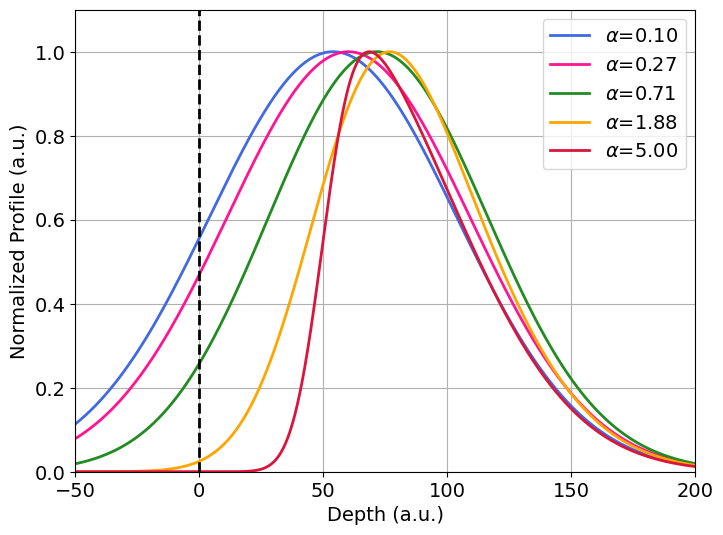

2.3010299956639813


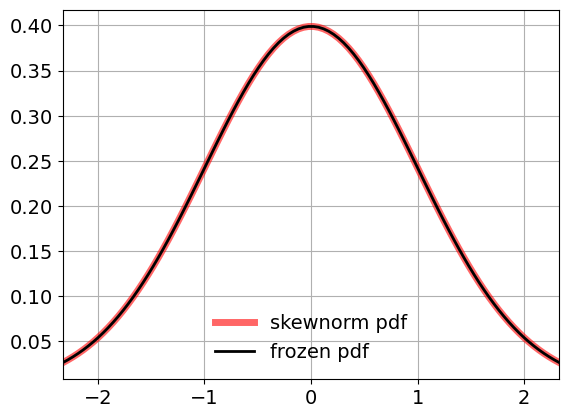

In [ ]:
from scipy.special import erf
from scipy.integrate import simpson
from scipy.stats import skewnorm
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

_skg_cache = {}

def skewed_gaussian(x, x0, s, alpha):
    if s <= 0:
        return np.zeros_like(x)
    # use scipy's skew-normal PDF (vectorized and optimized)
    arr = np.array(x)
    raw = skewnorm.pdf(arr, a=alpha, loc=x0, scale=s)

    # cache normalization factor per (x0,s,alpha)
    key = (float(x0), float(s), float(alpha))
    if key not in _skg_cache:
        grid = np.linspace(x0 - 10 * s, x0 + 10 * s, 2001)
        raw_g = skewnorm.pdf(grid, a=alpha, loc=x0, scale=s)
        max_raw = np.max(raw_g)
        _skg_cache[key] = 1.0 / max_raw if max_raw > 0 else 1.0

    return raw * _skg_cache[key]

def profile( de, width, sigma, alpha ):
    # if de <= 0:
    #     return 0
    # else:
    return skewed_gaussian( de, width, sigma, alpha )



# Define a gaussian that is centered in 0 with a sigma o 5 and that is skewed to the right
# def skewed_gaussian(x, width, sigma, alpha):
#     norm = 1 / (sigma * np.sqrt(2 * np.pi))
#     exponent = -0.5 * ((x - width) / sigma) ** 2
#     erf_component = 0.5 * (1 + erf(alpha * (x - width) / (sigma * np.sqrt(2))))
#     print(alpha, alpha/200, max(np.exp(exponent) * erf_component))
#     return norm * np.exp(exponent) * erf_component

# def skewed_gaussian(x, xi, omega, alpha):
#     phi = (1/(omega * np.sqrt(2*np.pi))) * np.exp(-(x - xi)**2/(2 * omega**2))
#     X = np.linspace(-1e3, alpha*((x-xi)/omega), 100000)
#     Phi = simpson((1/np.sqrt(2*np.pi)) * np.exp(-(X-xi)**2/(2*omega**2)), X)
#     return phi * Phi


# plt.plot(np.linspace(-10,50,1000), skewed_gaussian(np.linspace(-10,50,1000), 0, 10, 10))
# plt.show()

plt.figure( figsize=(8,6) )
x = np.linspace(-50, 200, 1000)
alphas = np.logspace(-1, np.log10(5), 5)
colors = ['royalblue', 'deeppink', 'forestgreen', 'orange', 'crimson']
width = 50
sigma = 50
for alpha, color in zip(alphas, colors):
    y = skewed_gaussian(x, x0=width, s=sigma, alpha=alpha)
    plt.plot(x, y/max(y), color=color, label=fr'$\alpha$={alpha:.2f}', lw=2)
plt.axvline(0, color='black', ls='--', lw=2)
plt.xlim(-50, 200)
plt.ylim(0, 1.1)
plt.legend()
plt.grid()
plt.xlabel('Depth (a.u.)')
plt.ylabel('Normalized Profile (a.u.)')
plt.savefig('results/skewed_gaussian_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print(np.log10(200))

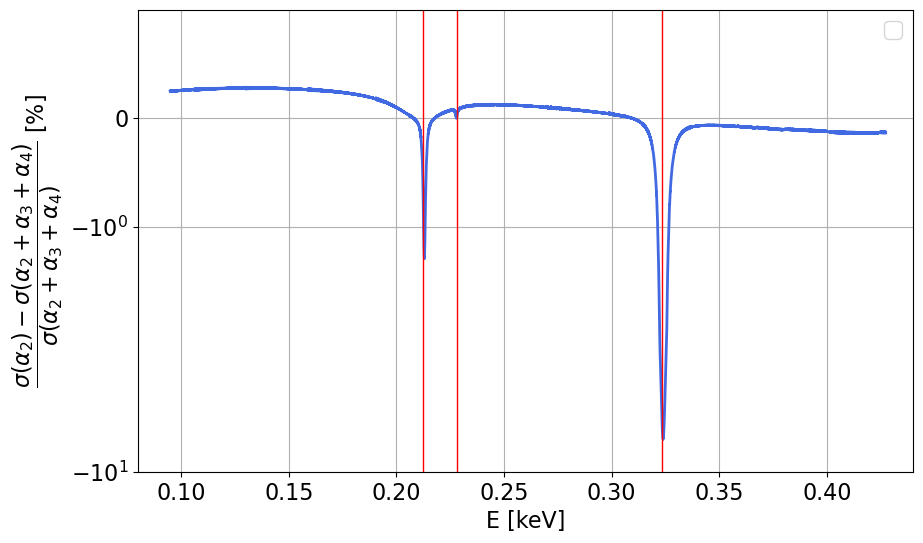

In [ ]:
import numpy as np

data = np.loadtxt( "utils/full_a3_a4.extrap", usecols=(0,3) )
E, sigma = data[:,0], data[:,1]

data = np.loadtxt( "utils/full_wo_a3_a4.extrap", usecols=(0,3) )
E_wo, sigma_wo = data[:,0], data[:,1]

plt.figure( figsize=(10,6) )
plt.plot(E, (sigma-sigma_wo)/sigma*100, color="royalblue", lw=2)
# plt.axhline(100, color="black", ls="--", lw=2)
plt.axvline(0.2125, color="red", lw=1)
plt.axvline(0.228, color="red", lw=1)
plt.axvline(0.3235, color="red", lw=1)
plt.yscale("symlog")
plt.legend()
plt.grid()
plt.xlabel("E [keV]")
plt.ylabel(r"$\dfrac{\sigma(\alpha_2) - \sigma(\alpha_2+\alpha_3+\alpha_4)}{\sigma(\alpha_2+\alpha_3+\alpha_4)}$ [%]")
plt.xlim(0.08, 0.44)
plt.ylim(-10, 1)
plt.show( )

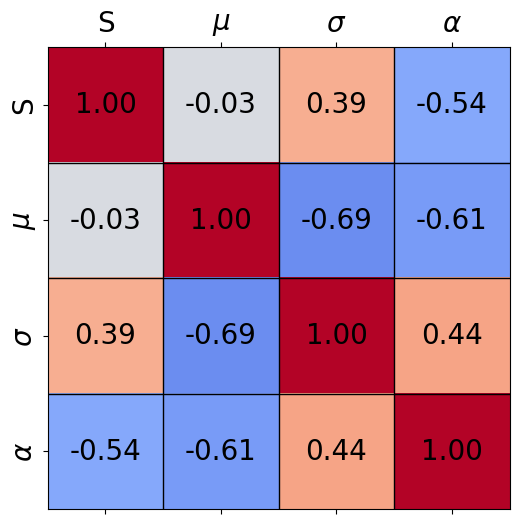

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

# Given a corelation matrix, I want to plot a grid showing the values and associate to each cell a color depending on the value
correlation_matrix = np.array([
    [1.00000, -0.03224,  0.38650, -0.53918],
    [-0.03224, 1.00000, -0.68846, -0.61209],
    [0.38650, -0.68846,  1.00000,  0.44228],
    [-0.53918, -0.61209,  0.44228,  1.00000]
])

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
# fig.colorbar(cax)
ticks = np.arange(0, 4, 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(['S', r'$\mu$', r'$\sigma$', r'$\alpha$'])
ax.set_yticklabels(['S', r'$\mu$', r'$\sigma$', r'$\alpha$'], rotation=90, va='center')
plt.axvline(0.5, color='black', lw=1)
plt.axvline(1.5, color='black', lw=1)
plt.axvline(2.5, color='black', lw=1)
plt.axhline(0.5, color='black', lw=1)
plt.axhline(1.5, color='black', lw=1)
plt.axhline(2.5, color='black', lw=1)
for (i, j), val in np.ndenumerate(correlation_matrix):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black')
plt.savefig('results/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

de = 5.0
s = 0.12331292416044637 (before straggling)
s = 1.6888197642751794 (after straggling)
##############
de = 7.5
s = 0.12331292416044637 (before straggling)
s = 2.06653460064844 (after straggling)
##############
de = 10.0
s = 0.12331292416044637 (before straggling)
s = 2.385166307649835 (after straggling)
##############
de = 12.5
s = 0.12331292416044637 (before straggling)
s = 2.6659841287259534 (after straggling)
##############
de = 15.0
s = 0.12331292416044637 (before straggling)
s = 2.9199185663455443 (after straggling)
##############
de = 17.5
s = 0.12331292416044637 (before straggling)
s = 3.1534707059936604 (after straggling)
##############
de = 20.0
s = 0.12331292416044637 (before straggling)
s = 3.3708797891694227 (after straggling)
##############


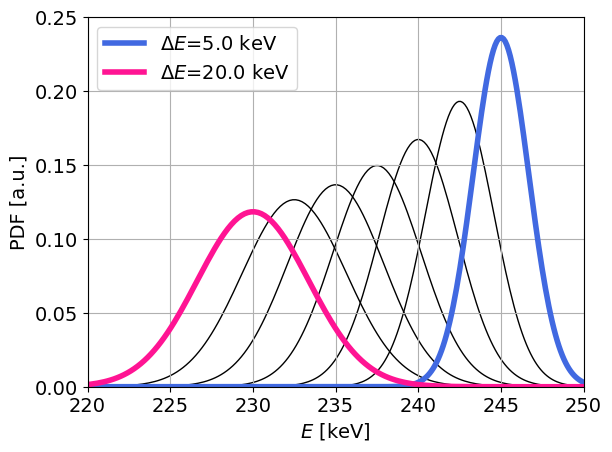

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

from scipy import integrate
from lmfit import Parameters, minimize

from scipy.special import gamma

from pyazr import azure2

from SRIM import SRIM
from scipy.special import erf

popt = [0.75324712]
def straggling( x ):
    return popt[0] * np.sqrt( x )

k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

def gaussian( x, x0, s ):
    return np.exp( -(x - x0)**2 / ( s*s*2 ) )

def integrand( x, theta, x0 ):
    de = x0 - x
    print(f'de = {de}')
    
    # Get beam width
    s = np.sqrt( pow( theta["beam"], 2 ) + pow( dopp, 2 ) )
    print(f's = {s} (before straggling)')
    s = np.sqrt( pow( theta["strag"] * straggling( de ), 2 ) + pow(s, 2) ) if de > 0 else s
    print(f's = {s} (after straggling)')
    print('##############')

    # Convolve the gaussian with the straggling
    array = np.linspace( x - 30 * s, x + 30 * s, 1000 )
    gauss = gaussian( array, x, s )
    gauss = gauss / (np.sum(gauss)*np.diff(array)[0])
    
    return array, gauss

theta = {'beam': 0.12, 'strag': 1}

x0 = 250
xs = np.linspace(245-15, 245,7)
xs = xs[::-1]

for x in xs:
    xg, gauss = integrand( x, theta, x0 )
    plt.plot( xg, gauss, 
             c='royalblue' if x == xs[0] else 'deeppink' if x == xs[-1] else 'black', 
             lw=4 if x == xs[0] or x == xs[-1] else 1, 
             zorder=2.1 if x == xs[0] or x == xs[-1] else 1,
             label=fr'$\Delta E$={x0-x:.1f} keV' if x == xs[0] or x == xs[-1] else None )
    plt.grid()
    plt.legend()
    plt.xlabel(r'$E$ [keV]')
    plt.ylabel('PDF [a.u.]')
    plt.xlim(220, 250)
    plt.ylim(0, 0.25)
plt.savefig('results/beam_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

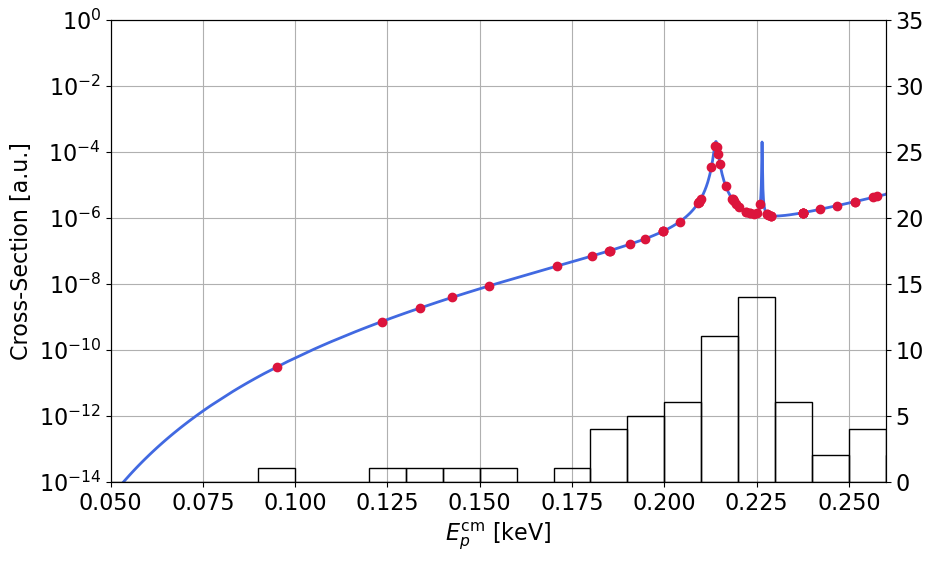

In [ ]:
data = np.loadtxt( "utils/all_imp.extrap", usecols=(0,3) )
energies, extrap = data[:,0], data[:,1]
mask = (energies > 0.05) & (energies < 0.40)
energies, extrap = energies[mask], extrap[mask]

longruns = np.array([150, 120, 130, 100.14, 140.88, 160.61, 179.97, 189.98, 194.97, 195.00, 195.01, 200.71, 205.02, 210.22, 210.22, 210.27, 215.06, 220.30, 220.41, 220.44, 220.53, 221.00, 224.04, 225.01, 225.77, 226.05, 226.50, 228.08, 230.01, 230.08, 230.09, 230.46, 231.02, 232.06, 234.00, 234.06, 235.01, 235.06, 236.13, 237.07, 237.99, 239.97, 240.00, 240.09, 241.10, 241.13, 241.17, 250.08, 250.10, 250.12, 250.12, 250.13, 250.15, 254.97, 260.00, 265.12, 265.12, 270.08, 271.27, 275.00, 280.00, 285.03, 290.00, 294.98, 300.00, 300.29, 319.99, 320.18, 330.03, 344.32, 344.76, 344.76, 345.30, 345.30, 370.27, 380.12, 390.02],float)

longruns = longruns * 19 / 20.007

extrap_fitted = np.interp(longruns, energies*1e3, extrap)


fig, ax = plt.subplots(figsize=(10,6))
ax.set_yscale("log")
ax.plot( energies, extrap, label='Extrapolated Cross-Section', color='royalblue', lw=2 )
ax.scatter( longruns/1e3, extrap_fitted, label='Long Runs', color='crimson', zorder=5 )
ax.grid()
ax.set_ylim(1e-14, 1e0)
ax.set_xlim(0.05, 0.26)
ax2 = ax.twinx()
ax2.set_yscale("linear")
counts, bins, patches = ax2.hist(longruns/1e3, bins=np.arange(0.05, 0.45, 0.01),
                                 facecolor='none', edgecolor='black', linewidth=1,
                                 label='Long Runs Distribution', zorder=10)
ax2.set_ylim(0, np.max(counts) * 2)
# ax2.set_xticks([])
ax2.set_yticks([0,5,10,15,20,25,30,35])
ax.set_xlabel(r'$E_p^\text{cm}$ [keV]')
ax.set_ylabel(r'Cross-Section [a.u.]')
plt.show()